In [209]:
import re
import os
import copy
import json
import random
import pickle
import logging
from pathlib import Path
from datetime import datetime
import networkx as nx
import matplotlib.pyplot as plt

In [210]:
ruta_archivo_norequ = r"C:\Users\alhel\Desktop\TESIS CARP 2025\Instancias\kshs\kshs1.dat" #this is the most general case

# Read instance .dat file based on format described in https://www.uv.es/~belengue/carp/READ_ME

In [211]:
ruta_archivo_norequ

'C:\\Users\\alhel\\Desktop\\TESIS CARP 2025\\Instancias\\kshs\\kshs1.dat'

In [212]:
import re

def leer_carplib_dat(filepath):
    parsed_data = {}
    current_list_key = None
    contador_tarea = 1
    
    with open(filepath, 'r', encoding='utf-8') as file:
        for line in file:
            line = line.strip()
            if not line or line.startswith(('=', '-', '|')):
                continue
            
            if ':' in line:
                key, val = line.split(':', 1)
                key = key.strip()
                val = val.strip()
                
                if key.startswith('LISTA_ARISTAS'):
                    current_list_key = key
                    parsed_data[key] = []
                    contador_tarea = 1
                else:
                    current_list_key = None
                    if val.isdigit() or (val.startswith('-') and val[1:].isdigit()):
                        parsed_data[key] = int(val)
                    else:
                        parsed_data[key] = val
                        
            elif current_list_key:
                numeros = [int(x) for x in re.findall(r'-?\d+', line)]
                if len(numeros) >= 3:
                    # Asignamos el prefijo dependiendo de la lista que se esté leyendo
                    if "NOREQ" in current_list_key:
                        prefijo = "TNR"
                    else:
                        prefijo = "TR"
                        
                    parsed_data[current_list_key].append({
                        'tarea': f"{prefijo}{contador_tarea}",
                        'nodos': (numeros[0], numeros[1]),
                        'costo': numeros[2],
                        'demanda': numeros[3] if len(numeros) >= 4 else 0
                    })
                    contador_tarea += 1

    nombre_objeto = 'loaded_dict'  
    return parsed_data, nombre_objeto

In [213]:
d_noreq, d_noreq_sname = leer_carplib_dat(ruta_archivo_norequ)
d_noreq, d_noreq_sname

({'NOMBRE': 'kshs1',
  'COMENTARIO': '69640.000000 (cota superior)',
  'VERTICES': 8,
  'ARISTAS_REQ': 15,
  'ARISTAS_NOREQ': 0,
  'VEHICULOS': 4,
  'CAPACIDAD': 150,
  'TIPO_COSTES_ARISTAS': 'EXPLICITOS',
  'COSTE_TOTAL_REQ': 8705,
  'LISTA_ARISTAS_REQ': [{'tarea': 'TR1',
    'nodos': (1, 3),
    'costo': 737,
    'demanda': 40},
   {'tarea': 'TR2', 'nodos': (1, 8), 'costo': 1082, 'demanda': 27},
   {'tarea': 'TR3', 'nodos': (2, 3), 'costo': 510, 'demanda': 25},
   {'tarea': 'TR4', 'nodos': (2, 4), 'costo': 166, 'demanda': 54},
   {'tarea': 'TR5', 'nodos': (2, 5), 'costo': 745, 'demanda': 5},
   {'tarea': 'TR6', 'nodos': (2, 6), 'costo': 780, 'demanda': 60},
   {'tarea': 'TR7', 'nodos': (2, 7), 'costo': 370, 'demanda': 30},
   {'tarea': 'TR8', 'nodos': (3, 4), 'costo': 663, 'demanda': 7},
   {'tarea': 'TR9', 'nodos': (3, 7), 'costo': 311, 'demanda': 50},
   {'tarea': 'TR10', 'nodos': (3, 8), 'costo': 696, 'demanda': 23},
   {'tarea': 'TR11', 'nodos': (4, 7), 'costo': 468, 'demanda': 3

In [214]:
d_noreq.values()

dict_values(['kshs1', '69640.000000 (cota superior)', 8, 15, 0, 4, 150, 'EXPLICITOS', 8705, [{'tarea': 'TR1', 'nodos': (1, 3), 'costo': 737, 'demanda': 40}, {'tarea': 'TR2', 'nodos': (1, 8), 'costo': 1082, 'demanda': 27}, {'tarea': 'TR3', 'nodos': (2, 3), 'costo': 510, 'demanda': 25}, {'tarea': 'TR4', 'nodos': (2, 4), 'costo': 166, 'demanda': 54}, {'tarea': 'TR5', 'nodos': (2, 5), 'costo': 745, 'demanda': 5}, {'tarea': 'TR6', 'nodos': (2, 6), 'costo': 780, 'demanda': 60}, {'tarea': 'TR7', 'nodos': (2, 7), 'costo': 370, 'demanda': 30}, {'tarea': 'TR8', 'nodos': (3, 4), 'costo': 663, 'demanda': 7}, {'tarea': 'TR9', 'nodos': (3, 7), 'costo': 311, 'demanda': 50}, {'tarea': 'TR10', 'nodos': (3, 8), 'costo': 696, 'demanda': 23}, {'tarea': 'TR11', 'nodos': (4, 7), 'costo': 468, 'demanda': 39}, {'tarea': 'TR12', 'nodos': (4, 8), 'costo': 1046, 'demanda': 55}, {'tarea': 'TR13', 'nodos': (5, 8), 'costo': 239, 'demanda': 29}, {'tarea': 'TR14', 'nodos': (6, 7), 'costo': 490, 'demanda': 65}, {'tare

## CHECKING THAT THE NUMBER OF LINES IS THE SAME AS THE NUMBER OF ITEMS IN DICT

In [151]:
def validate_instance(created_dict, dat_file_path): ### las no requeridas deben tener otro id, no Ti
    """
    Valida la integridad de la instancia comparando metadatos, 
    la longitud de las listas y el total de líneas útiles en el archivo original.
    """
    
    # 1. Extraemos los valores esperados (lo que dice el encabezado)
    n_req_esperadas = created_dict.get("ARISTAS_REQ", 0)
    n_noreq_esperadas = created_dict.get("ARISTAS_NOREQ", 0)
    
    # 2. Contamos cuánto se leyó realmente en las listas
    lista_req = created_dict.get("LISTA_ARISTAS_REQ", [])
    lista_noreq = created_dict.get("LISTA_ARISTAS_NOREQ", [])
    n_req_reales = len(lista_req)
    n_noreq_reales = len(lista_noreq)
    
    # 3. Validamos integridad de nodos (el nodo más alto no debe superar VERTICES)
    todas_las_aristas = lista_req + lista_noreq
    
    nodos_encontrados = []
    for item in todas_las_aristas:
        # Corregido: usamos 'nodos' en lugar de 'arco' basado en nuestra función anterior
        nodos_encontrados.extend(item['nodos'])
    
    max_nodo = max(nodos_encontrados) if nodos_encontrados else 0
    total_vertices = created_dict.get("VERTICES", 0)

    # 4. NUEVA LÓGICA: Contar líneas útiles en el archivo .dat
    lineas_utiles_archivo = 0
    with open(dat_file_path, 'r', encoding='utf-8') as file:
        for line in file:
            line = line.strip()
            # Aplicamos el mismo filtro que en la función de lectura
            if not line or line.startswith('=') or line.startswith('-') or line.startswith('|'):
                continue
            lineas_utiles_archivo += 1

    # El total de elementos capturados es: llaves principales + items en las listas
    elementos_en_dict = len(created_dict) + n_req_reales + n_noreq_reales

    # 5. Verificación de condiciones
    check_req = (n_req_esperadas == n_req_reales)
    check_noreq = (n_noreq_esperadas == n_noreq_reales)
    check_nodes = (max_nodo <= total_vertices)
    check_lineas = (lineas_utiles_archivo == elementos_en_dict)

    is_valid = check_req and check_noreq and check_nodes and check_lineas

    # 6. Resultado detallado
    validation_results = {
        "is_valid": is_valid,
        "status": "VALIDACIÓN EXITOSA" if is_valid else "ERROR DE INTEGRIDAD",
        "detalles": {
            "aristas_req": f"{n_req_reales}/{n_req_esperadas}",
            "aristas_noreq": f"{n_noreq_reales}/{n_noreq_esperadas}",
            "nodos_ok": f"Max Nodo {max_nodo} <= {total_vertices}",
            "lineas_vs_dict": f"Archivo: {lineas_utiles_archivo} == Dict: {elementos_en_dict}"
        }
    }

    nombre_objeto = 'validation_dict'
    return validation_results, nombre_objeto

In [152]:
reading_validation_dict_noreq, val_d_name = validate_instance(d_noreq, ruta_archivo_norequ)
reading_validation_dict_noreq, val_d_name

({'is_valid': True,
  'status': 'VALIDACIÓN EXITOSA',
  'detalles': {'aristas_req': '15/15',
   'aristas_noreq': '0/0',
   'nodos_ok': 'Max Nodo 8 <= 8',
   'lineas_vs_dict': 'Archivo: 26 == Dict: 26'}},
 'validation_dict')

In [153]:
val_d_name

'validation_dict'

# GESTIÓN DE EJECUCIÓN Y GUARDADO

In [154]:
def iniciar_ejecucion(metadata_dict, base_dir="corridas_files"):
    project_name = metadata_dict.get("NOMBRE", "Instancia")
    run_id = datetime.now().strftime("%H%M%S")
    date_str = datetime.now().strftime("%Y-%m-%d")

    try:
        directorio_base = Path(__file__).resolve().parent
    except NameError:
        directorio_base = Path.cwd()
        
    run_path = directorio_base / base_dir / f"{project_name}_{date_str}__ID-{run_id}"
    run_path.mkdir(parents=True, exist_ok=True)

    logger = logging.getLogger(f"{project_name}_{run_id}")
    logger.setLevel(logging.INFO)
    
    if not logger.handlers:
        file_handler = logging.FileHandler(run_path / "execution.log")
        file_handler.setFormatter(logging.Formatter('%(asctime)s - %(message)s'))
        logger.addHandler(file_handler)

    logger.info("Run initialized.")
    return run_path, logger

In [155]:
tst_path, tst_logger = iniciar_ejecucion(d_noreq, base_dir="instance_runs_test_debug_20260313")

In [156]:
tst_path

WindowsPath('C:/Users/alhel/Desktop/TESIS CARP 2025/Metaheuristicas/TestingClass/instance_runs_test_debug_20260313/kshs1_2026-03-13__ID-162632')

In [157]:
import os
import json
import pickle

def guardar_objeto_automatico(carpeta, nombre_instancia, objeto, tipo_objeto):
    """
    Guarda un objeto en disco infiriendo su formato ideal.
    El archivo resultante tendrá el formato: carpeta/nombre_instancia_tipo_objeto.ext
    """
    # Construimos el nombre base estandarizado
    nombre_base = f"{nombre_instancia}_{tipo_objeto}"
    
    # 1. Gráficas o figuras (Matplotlib/Plotly compatibles)
    if hasattr(objeto, 'savefig'):
        ruta = os.path.join(carpeta, f"{nombre_base}.jpg")
        objeto.savefig(ruta, format='jpg', dpi=300, bbox_inches='tight')
        return ruta
        
    # 2. Cadenas de texto plano (Logs, reportes)
    elif isinstance(objeto, str):
        ruta = os.path.join(carpeta, f"{nombre_base}.txt")
        with open(ruta, 'w', encoding='utf-8') as f:
            f.write(objeto)
        return ruta
        
    # 3. Diccionarios o Listas (Intentamos guardar como JSON para legibilidad)
    elif isinstance(objeto, (dict, list)):
        ruta_json = os.path.join(carpeta, f"{nombre_base}.json")
        try:
            with open(ruta_json, 'w', encoding='utf-8') as f:
                json.dump(objeto, f, indent=4)
            return ruta_json
        except TypeError:
            # Si el diccionario tiene objetos no serializables en JSON (como tuplas como llaves), 
            # fallará silenciosamente y pasará al guardado en Pickle.
            pass 
            
    # 4. Fallback de seguridad (Pickle binario para cualquier objeto complejo)
    ruta_pkl = os.path.join(carpeta, f"{nombre_base}.pkl")
    with open(ruta_pkl, 'wb') as f:
        pickle.dump(objeto, f)
        
    return ruta_pkl

In [158]:
 guardar_objeto_automatico(tst_path, d_noreq['NOMBRE'],d_noreq, d_noreq_sname)

'C:\\Users\\alhel\\Desktop\\TESIS CARP 2025\\Metaheuristicas\\TestingClass\\instance_runs_test_debug_20260313\\kshs1_2026-03-13__ID-162632\\kshs1_loaded_dict.json'

In [159]:
 guardar_objeto_automatico(tst_path, d_noreq['NOMBRE'],reading_validation_dict_noreq, val_d_name)

'C:\\Users\\alhel\\Desktop\\TESIS CARP 2025\\Metaheuristicas\\TestingClass\\instance_runs_test_debug_20260313\\kshs1_2026-03-13__ID-162632\\kshs1_validation_dict.json'

In [160]:
def finalizar_ejecucion(run_path, logger, success=True, reason=""):
    status_str = "SUCCESS" if success else "FAILED"
    (run_path / f"STATUS_{status_str}").touch()
    
    mensaje = f"Run finished with status: {status_str}"
    if reason: 
        mensaje += f" | Reason: {reason}"
        
    logger.info(mensaje)

# Draw the graph based on the arcs and nodes extracted in the previous step

In [161]:
def generar_grafo_limpio(data, carpeta_salida=None, figsize=(35,30), k_layout=15):
    G = nx.Graph()
    for i in range(1, data.get('VERTICES', 0) + 1):
        G.add_node(i)
        
    for item in data.get('LISTA_ARISTAS_REQ', []):
        u, v = item['nodos']
        G.add_edge(u, v, cost=item['costo'], demand=item['demanda'], tipo='req')

    for item in data.get('LISTA_ARISTAS_NOREQ', []):
        u, v = item['nodos']
        G.add_edge(u, v, cost=item['costo'], demand=item.get('demanda', 0), tipo='noreq')

    pos = nx.spring_layout(G, k=k_layout, iterations=200, seed=42)
    plt.figure(figsize=figsize) 
    
    deposito = data.get('DEPOSITO', 1)
    node_colors = ['#ff4d4d' if node == deposito else '#74b9ff' for node in G.nodes()]
    
    nx.draw_networkx_nodes(G, pos, node_size=900, node_color=node_colors, edgecolors='#74b9ff', linewidths=1)
    nx.draw_networkx_labels(G, pos, font_size=15, font_weight='bold')
    
    arcos_req = [(u, v) for u, v, d in G.edges(data=True) if d['tipo'] == 'req']
    arcos_noreq = [(u, v) for u, v, d in G.edges(data=True) if d['tipo'] == 'noreq']
    
    nx.draw_networkx_edges(G, pos, edgelist=arcos_req, width=2.0, edge_color='black')
    nx.draw_networkx_edges(G, pos, edgelist=arcos_noreq, width=1.5, edge_color='gray', style='dashed')
    
    edge_labels = {}
    for u, v, d in G.edges(data=True):
        if d['tipo'] == 'req':
            edge_labels[(u, v)] = f"C:{d['cost']}\nD:{d['demand']}"
        else:
            edge_labels[(u, v)] = f"C:{d['cost']}"
            
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=15, font_color='#2d3436', label_pos=0.5, bbox=dict(alpha=0))
    
    texto_resumen = (
        f"RESUMEN DE LA INSTANCIA\n"
        f"--------------------------------------\n"
        f"Nombre: {data.get('NOMBRE', 'N/A')}\n"
        f"Vértices: {data.get('VERTICES', 0)}\n"
        f"Vehículos: {data.get('VEHICULOS', 0)}\n"
        f"Capacidad: {data.get('CAPACIDAD', 0)}\n"
        f"Aristas Req: {data.get('ARISTAS_REQ', 0)}\n"
        f"Aristas No Req: {data.get('ARISTAS_NOREQ', 0)}"
    )
    
    plt.text(0.02, 0.98, texto_resumen, transform=plt.gca().transAxes, fontsize=20, 
             verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='#f1f2f6', alpha=0.9))

    nombre_instancia = data.get('NOMBRE', 'instancia')
    plt.title(f"Grafo de Instancia: {nombre_instancia}\n"
              f"(Rojo = Depósito | Negro Sólido = Req | Gris Punteado = No Req)", 
              fontsize=25, pad=20)
    plt.axis('off')
    plt.tight_layout()

    # NUEVO: Guardar la imagen de Matplotlib directamente aquí
    # (Asumiendo que le pasas 'carpeta_salida' a la función)
    if carpeta_salida in locals():
        ruta_imagen = os.path.join(carpeta_salida, f"{nombre_instancia}_mapa_estatico.png")
        plt.savefig(ruta_imagen, format='png', dpi=300, bbox_inches='tight')
    else:
        pass
    plt.show()
    plt.close() # Cierra la figura visual
    
    #object_name = "grafo_matematico"
    return G

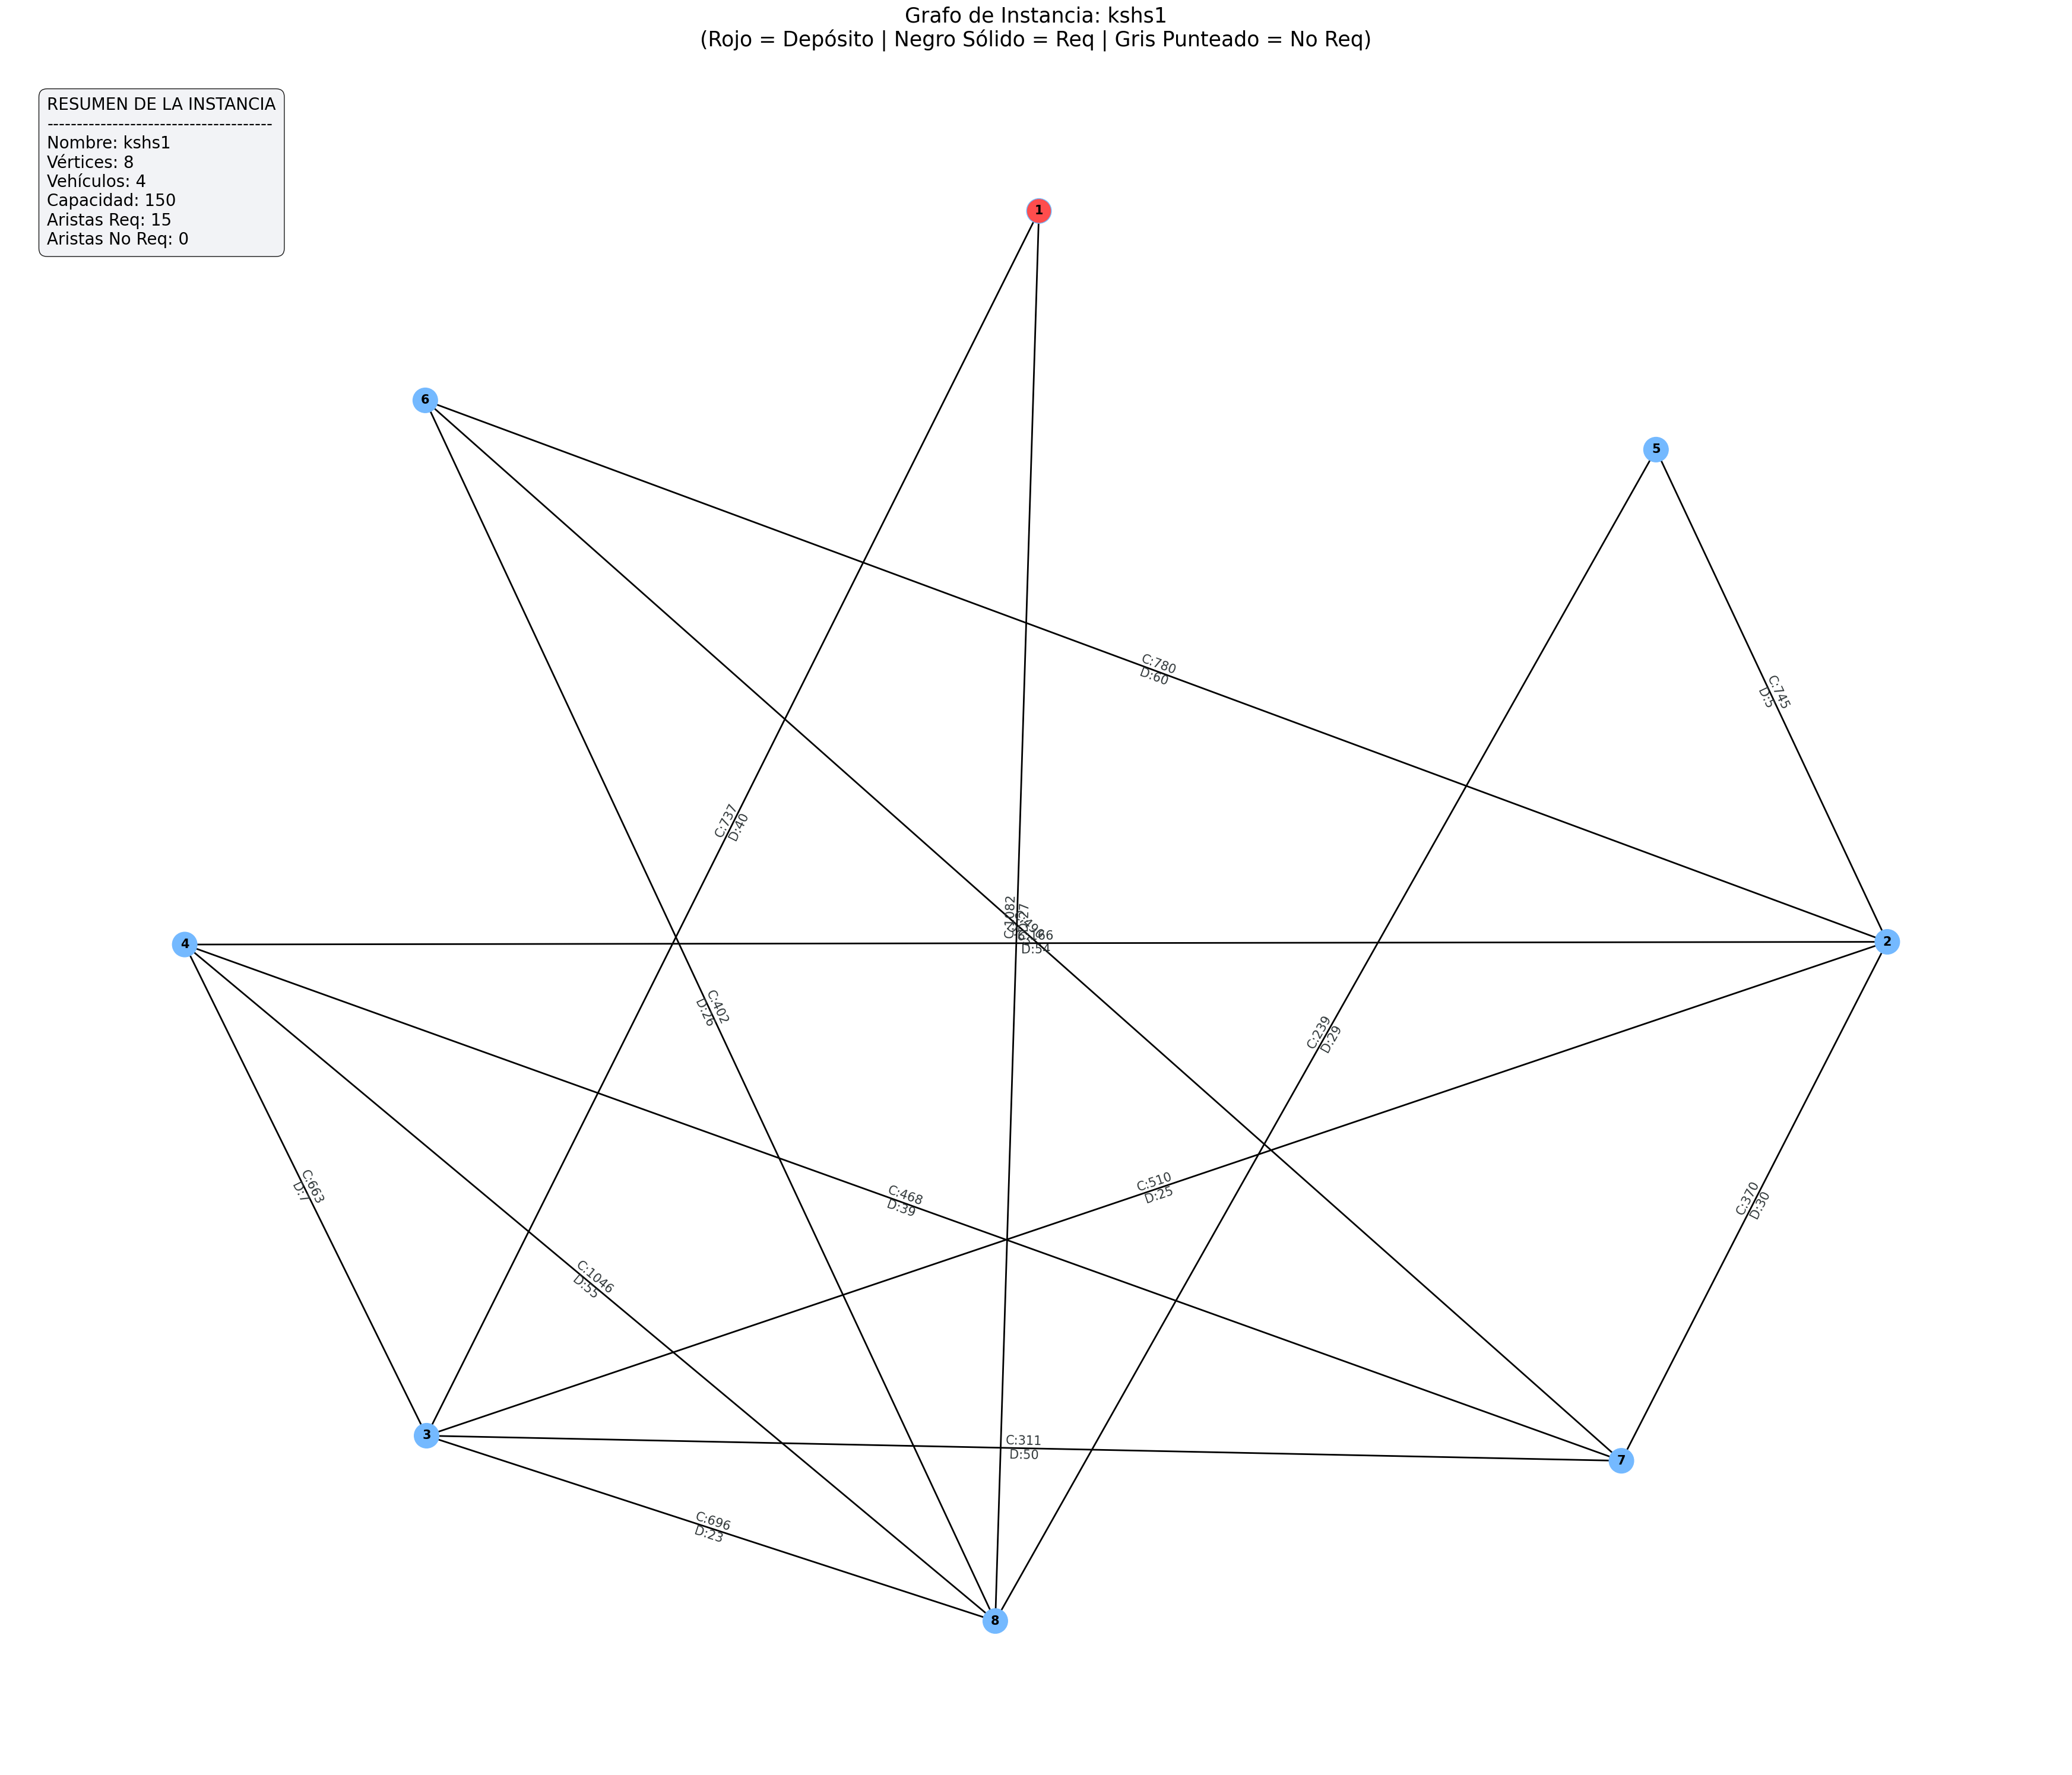

In [162]:
G_test = generar_grafo_limpio(d_noreq, carpeta_salida = None, figsize=(35,30), k_layout=15)
G_test

# Generar la distancia mas corta (costo) entre cada par de nodos

In [163]:
import networkx as nx
import matplotlib.pyplot as plt

In [164]:
import networkx as nx

def calcular_matriz_distancias(G, algoritmo='dijkstra', carpeta_salida=None, nombre_instancia="instancia"):
    algoritmo = algoritmo.strip().lower()
    nodos = list(G.nodes())
    matriz_distancias = {}
    
    if algoritmo == 'dijkstra':
        dijkstra_raw = dict(nx.all_pairs_dijkstra_path_length(G, weight='cost'))
        for u in nodos:
            matriz_distancias[u] = {}
            for v in nodos:
                matriz_distancias[u][v] = dijkstra_raw.get(u, {}).get(v, float('inf'))
                
    elif algoritmo in ['floyd-warshall', 'floyd_warshall', 'floyd']:
        fw_raw = nx.floyd_warshall(G, weight='cost')
        for u in nodos:
            matriz_distancias[u] = dict(fw_raw[u])
            
    # Añadido para hacer match con el selector de la interfaz gráfica (app.py)
    elif algoritmo in ['bellman-ford', 'bellman_ford', 'bellman']:
        bf_raw = dict(nx.all_pairs_bellman_ford_path_length(G, weight='cost'))
        for u in nodos:
            matriz_distancias[u] = {}
            for v in nodos:
                matriz_distancias[u][v] = bf_raw.get(u, {}).get(v, float('inf'))
                
    else:
        raise ValueError(f"Algoritmo '{algoritmo}' no reconocido.")
        
    # NUEVO: Guardado Automático en disco
    if carpeta_salida:
        # El nombre quedará como: nombre_instancia_matriz_distancias_dijkstra.json
        tipo_objeto = f"matriz_distancias_{algoritmo}"
        # Se asume que guardar_objeto_automatico está definida en este mismo archivo
        guardar_objeto_automatico(carpeta_salida, nombre_instancia,  matriz_distancias, tipo_objeto)
        
    return matriz_distancias

In [165]:
matriz_distancias_t = calcular_matriz_distancias(G_test, algoritmo='dijkstra', carpeta_salida=None, nombre_instancia = d_noreq['NOMBRE'])
matriz_distancias_t

{1: {1: 0, 2: 1247, 3: 737, 4: 1400, 5: 1321, 6: 1484, 7: 1048, 8: 1082},
 2: {1: 1247, 2: 0, 3: 510, 4: 166, 5: 745, 6: 780, 7: 370, 8: 984},
 3: {1: 737, 2: 510, 3: 0, 4: 663, 5: 935, 6: 801, 7: 311, 8: 696},
 4: {1: 1400, 2: 166, 3: 663, 4: 0, 5: 911, 6: 946, 7: 468, 8: 1046},
 5: {1: 1321, 2: 745, 3: 935, 4: 911, 5: 0, 6: 641, 7: 1115, 8: 239},
 6: {1: 1484, 2: 780, 3: 801, 4: 946, 5: 641, 6: 0, 7: 490, 8: 402},
 7: {1: 1048, 2: 370, 3: 311, 4: 468, 5: 1115, 6: 490, 7: 0, 8: 892},
 8: {1: 1082, 2: 984, 3: 696, 4: 1046, 5: 239, 6: 402, 7: 892, 8: 0}}

# Factibilidad

In [166]:
import random

def es_ruta_factible(ruta, data, matriz_distancias):
    """Verifica si una sola ruta cumple con capacidad y conectividad."""
    if not ruta: return True
    
    capacidad_max = data.get('CAPACIDAD', 0)
    deposito = data.get('DEPOSITO', 1)
    info_tareas = {t['tarea']: t for t in data.get('LISTA_ARISTAS_REQ', [])}
    
    demanda_total = 0
    nodos_anteriores = (deposito, deposito)
    
    for id_tarea in ruta:
        tarea = info_tareas.get(id_tarea)
        if not tarea: return False
        
        u_act, v_act = tarea['nodos']
        demanda_total += tarea['demanda']
        
        # 1. Chequeo de Capacidad
        if demanda_total > capacidad_max: 
            return False
            
        # 2. Chequeo de Conectividad (¿Podemos llegar desde la tarea anterior a esta?)
        u_ant, v_ant = nodos_anteriores
        hay_camino = (
            matriz_distancias[u_ant][u_act] != float('inf') or 
            matriz_distancias[u_ant][v_act] != float('inf') or
            matriz_distancias[v_ant][u_act] != float('inf') or 
            matriz_distancias[v_ant][v_act] != float('inf')
        )
        
        if not hay_camino: return False
        nodos_anteriores = (u_act, v_act)
        
    # 3. Retorno al depósito (¿Podemos volver a casa desde la última tarea?)
    u_ant, v_ant = nodos_anteriores
    if matriz_distancias[u_ant][deposito] == float('inf') and matriz_distancias[v_ant][deposito] == float('inf'):
        return False
        
    return True

In [167]:
def es_solucion_factible(solucion, data, matriz_distancias):
    """Verifica si toda la solución (flota de vehículos) es válida."""
    num_vehiculos = data.get('VEHICULOS', 0)
    
    # 1. Checar que no se utilicen más camiones de los permitidos
    rutas_activas = [r for r in solucion if r]
    if len(rutas_activas) > num_vehiculos:
        return False
        
    # 2. Validar cada ruta individualmente
    for ruta in solucion:
        if not es_ruta_factible(ruta, data, matriz_distancias):
            return False
            
    return True

# SOLUCION ALEATORIA

In [168]:
def generar_solucion_inicial_aleatoria(data, matriz_distancias, max_intentos=10000, carpeta_salida=None, nombre_instancia="instancia"):
    """Construye aleatoriamente una solución y delega la validación."""
    num_vehiculos = data.get('VEHICULOS', 0)
    capacidad_max = data.get('CAPACIDAD', 0)
    tareas_requeridas = data.get('LISTA_ARISTAS_REQ', [])
    
    # Chequeo rápido de viabilidad base
    for t in tareas_requeridas:
        if t['demanda'] > capacidad_max: 
            # Siguiendo tu instrucción de formato para tareas (mostrar el arco)
            arco = t.get('nodos', 'Desconocido')
            raise ValueError(f"Instancia inviable: La tarea {t['tarea']} (Arco: {arco}) excede la capacidad máxima.")

    intentos = 0
    
    while intentos < max_intentos:
        intentos += 1
        tareas_mezcladas = tareas_requeridas.copy()
        random.shuffle(tareas_mezcladas)
        
        solucion = [[] for _ in range(num_vehiculos)]
        v_idx = 0
        demanda_actual = 0
        
        # 1. Construcción (Agrupamiento voraz guiado por capacidad)
        for tarea in tareas_mezcladas:
            if demanda_actual + tarea['demanda'] <= capacidad_max:
                solucion[v_idx].append(tarea['tarea'])
                demanda_actual += tarea['demanda']
            else:
                v_idx += 1
                if v_idx >= num_vehiculos:
                    # Nos quedamos sin camiones, metemos la tarea al último para forzar 
                    # que el validador lo rechace y volvamos a intentarlo.
                    solucion[-1].append(tarea['tarea'])
                    break 
                    
                solucion[v_idx].append(tarea['tarea'])
                demanda_actual = tarea['demanda']
                
        # 2. Validación (Delegada a las funciones expertas)
        if es_solucion_factible(solucion, data, matriz_distancias):
            # NUEVO: Guardado automático de la primera solución aleatoria válida
            if carpeta_salida:
                guardar_objeto_automatico(carpeta_salida, nombre_instancia, solucion, "initial_random_solution")
            return solucion
            
    raise RuntimeError(f"No se halló solución factible tras {max_intentos} intentos.")

In [169]:
random_sol_t = generar_solucion_inicial_aleatoria(d_noreq, matriz_distancias_t, max_intentos=10000,
                                                  carpeta_salida=tst_path, nombre_instancia=d_noreq['NOMBRE'])
random_sol_t

[['TR2', 'TR15', 'TR11', 'TR8', 'TR10', 'TR5'],
 ['TR13', 'TR6', 'TR12'],
 ['TR1', 'TR9', 'TR3'],
 ['TR14', 'TR7', 'TR4']]

In [170]:
es_solucion_factible(random_sol_t, d_noreq, matriz_distancias_t)

True

In [171]:
def detalle_sol(solucion, data, G, carpeta_salida=None, nombre_instancia="instancia" ):
    
    deposito = data.get('DEPOSITO', 1)
    capacidad_max = data.get('CAPACIDAD', 0)
    info_tareas = {t['tarea']: {'u': t['nodos'][0], 'v': t['nodos'][1], 'costo': t['costo'], 'demanda': t['demanda']}
                   for t in data.get('LISTA_ARISTAS_REQ', [])}
        
    costos_rutas = []
    costo_total_solucion = 0
    reporte = [] # Guardaremos el reporte en una lista para retornarlo como string
    
    reporte.append("="*80)
    reporte.append("EVALUACIÓN COMPACTA DE RUTAS")
    reporte.append("="*80)
    
    for i, ruta in enumerate(solucion):
        reporte.append(f"RUTA {i + 1} {ruta}")
        if not ruta:
            reporte.append(f"  -> Vehículo vacío | Costo Total: 0 | Demanda: 0 / {capacidad_max}\n")
            costos_rutas.append(0)
            continue
            
        costo_vehiculo, demanda_vehiculo, nodo_actual = 0, 0, deposito
        for id_tarea in ruta:
            tarea = info_tareas[id_tarea]
            u, v, costo_serv, dem_serv = tarea['u'], tarea['v'], tarea['costo'], tarea['demanda']
            
            if nodo_actual != u:
                camino_dh = nx.shortest_path(G, source=nodo_actual, target=u, weight='cost')
                costo_dh = nx.shortest_path_length(G, source=nodo_actual, target=u, weight='cost')
                str_dh = " -> ".join(map(str, camino_dh))
            else:
                costo_dh, str_dh = 0, f"Ninguno (ya en {u})"
                
            costo_total_paso = costo_dh + costo_serv
            costo_vehiculo += costo_total_paso
            demanda_vehiculo += dem_serv
            
            reporte.append(f"  -> {id_tarea} ({u},{v}) -> DH: [{str_dh}] | Demanda: {dem_serv} | Costo (DH + Serv): {costo_dh} + {costo_serv} = {costo_total_paso}")
            nodo_actual = v
            
        if nodo_actual != deposito:
            camino_ret = nx.shortest_path(G, source=nodo_actual, target=deposito, weight='cost')
            costo_ret = nx.shortest_path_length(G, source=nodo_actual, target=deposito, weight='cost')
            str_ret = " -> ".join(map(str, camino_ret))
        else:
            costo_ret, str_ret = 0, f"Ninguno (ya en {deposito})"
            
        costo_vehiculo += costo_ret
        reporte.append(f"  -> REGRESO A DEPÓSITO ({deposito}) -> DH: [{str_ret}] | Costo Regreso: {costo_ret}")
        
        estado_cap = "OK" if demanda_vehiculo <= capacidad_max else "EXCEDIDA"
        reporte.append(f"  => TOTAL RUTA {i + 1}: Costo Total = {costo_vehiculo} | Demanda Total = {demanda_vehiculo} / {capacidad_max} [{estado_cap}]\n")
        costos_rutas.append(costo_vehiculo)
        costo_total_solucion += costo_vehiculo
        
    reporte.append("="*80)
    reporte.append(f"COSTO TOTAL DE LA SOLUCIÓN: {costo_total_solucion}")
    reporte.append("="*80 + "\n")
    
    # Imprimimos y también retornamos el texto para poder guardarlo
    texto_final = "\n".join(reporte)

    if carpeta_salida:
       guardar_objeto_automatico(carpeta_salida, nombre_instancia, texto_final, "initial_random_solution_detail")

    return costos_rutas, costo_total_solucion, texto_final

In [172]:
c_, cts_, tf = detalle_sol(random_sol_t, d_noreq, G_test, carpeta_salida=tst_path, nombre_instancia=d_noreq['NOMBRE'])

In [173]:
c_

[8783, 6398, 2665, 4650]

In [174]:
cts_

22496

In [175]:
print(tf)

EVALUACIÓN COMPACTA DE RUTAS
RUTA 1 ['TR2', 'TR15', 'TR11', 'TR8', 'TR10', 'TR5']
  -> TR2 (1,8) -> DH: [Ninguno (ya en 1)] | Demanda: 27 | Costo (DH + Serv): 0 + 1082 = 1082
  -> TR15 (6,8) -> DH: [8 -> 6] | Demanda: 26 | Costo (DH + Serv): 402 + 402 = 804
  -> TR11 (4,7) -> DH: [8 -> 4] | Demanda: 39 | Costo (DH + Serv): 1046 + 468 = 1514
  -> TR8 (3,4) -> DH: [7 -> 3] | Demanda: 7 | Costo (DH + Serv): 311 + 663 = 974
  -> TR10 (3,8) -> DH: [4 -> 3] | Demanda: 23 | Costo (DH + Serv): 663 + 696 = 1359
  -> TR5 (2,5) -> DH: [8 -> 5 -> 2] | Demanda: 5 | Costo (DH + Serv): 984 + 745 = 1729
  -> REGRESO A DEPÓSITO (1) -> DH: [5 -> 8 -> 1] | Costo Regreso: 1321
  => TOTAL RUTA 1: Costo Total = 8783 | Demanda Total = 127 / 150 [OK]

RUTA 2 ['TR13', 'TR6', 'TR12']
  -> TR13 (5,8) -> DH: [1 -> 8 -> 5] | Demanda: 29 | Costo (DH + Serv): 1321 + 239 = 1560
  -> TR6 (2,6) -> DH: [8 -> 5 -> 2] | Demanda: 60 | Costo (DH + Serv): 984 + 780 = 1764
  -> TR12 (4,8) -> DH: [6 -> 2 -> 4] | Demanda: 55 | 

In [215]:
import random

# ==========================================
# OPERADORES EVOLUTIVOS SIMPLIFICADOS (CARP)
# ==========================================

def op_inter_swap(r1, r2):
    """Intercambia exactamente 1 tarea de la ruta 1 con 1 tarea de la ruta 2."""
    h1, h2 = r1.copy(), r2.copy()
    
    # Prevención de errores si alguna ruta está vacía
    if not h1 or not h2: 
        return h1, h2, {'info': 'Rutas no aptas para swap'}

    idx1 = random.randrange(len(h1))
    idx2 = random.randrange(len(h2))

    # Ejecutamos el intercambio (Swap)
    h1[idx1], h2[idx2] = h2[idx2], h1[idx1]

    meta = {'tarea_r1_out': h2[idx2], 'tarea_r2_out': h1[idx1]}
    return h1, h2, meta

def op_inter_shift(r1, r2):
    """Extrae 1 tarea de la ruta 1 y la inserta en la ruta 2."""
    h1, h2 = r1.copy(), r2.copy()
    
    if not h1: 
        return h1, h2, {'info': 'Ruta 1 vacía'}

    # Sacamos de la primera ruta
    idx1 = random.randrange(len(h1))
    tarea = h1.pop(idx1)

    # Metemos en la segunda ruta
    idx2 = random.randrange(len(h2) + 1) if h2 else 0
    h2.insert(idx2, tarea)

    meta = {'tarea_movida': tarea, 'pos_destino': idx2}
    return h1, h2, meta

def op_intra_mutacion(ruta):
    """Invierte el orden de un segmento dentro de la misma ruta (2-opt local)."""
    h = ruta.copy()
    
    if len(h) < 2: 
        return h, {'info': 'Ruta muy corta para mutar'}

    idx1, idx2 = sorted(random.sample(range(len(h)), 2))
    h[idx1:idx2+1] = reversed(h[idx1:idx2+1])

    meta = {'inicio': idx1, 'fin': idx2, 'segmento': h[idx1:idx2+1]}
    return h, meta

def aplicar_operador(tipo, padres, k=None):
    """
    Despachador central simplificado. Ignoramos 'k' para priorizar operaciones 1 a 1.
    """
    if tipo == "mutacion":
        # Intra-ruta: Siempre aplica la inversión 2-opt
        hijo, meta = op_intra_mutacion(padres[0])
        return [hijo], "intra_inversion", [meta]

    elif tipo == "cruce":
        # Inter-ruta: 50% probabilidad de SWAP, 50% probabilidad de SHIFT
        if random.random() < 0.5:
            
            h1, h2, meta = op_inter_swap(padres[0], padres[1])
            nombre_op = "inter_swap"
        else:
            
            h1, h2, meta = op_inter_shift(padres[0], padres[1])
            nombre_op = "inter_shift"

        return [h1, h2], nombre_op, [meta]

    else:
        raise ValueError("tipo debe ser 'mutacion' o 'cruce'")

In [216]:
import random
import copy

def aplicar_y_evaluar_vecindario(solucion, data, G, matriz_distancias, p_inter=0.5, max_intentos=100, k=2, generar_reporte=True):
    """
    Genera un vecino aplicando operadores a TODAS las rutas de la solución.
    Ideal para debugging exhaustivo de macro-perturbaciones.
    """
    intentos = 0
    vecino_encontrado = False
    nueva = []
    detalles_cambio = ""
    
    while intentos < max_intentos:
        intentos += 1
        nueva = [ruta[:] for ruta in solucion]
        
        rutas_con_tareas = [i for i, r in enumerate(nueva) if len(r) > 0]
        
        if not rutas_con_tareas:
            if generar_reporte: detalles_cambio = "No hay tareas en la solución para mover."
            break
            
        rutas_procesadas = set()
        rutas_a_procesar = list(rutas_con_tareas)
        random.shuffle(rutas_a_procesar)
        
        cambios_iteracion = []
        
        # Iteramos sobre todas las rutas para alterarlas en el mismo vecino
        for r1 in rutas_a_procesar:
            if r1 in rutas_procesadas:
                continue
                
            es_inter = (random.random() < p_inter)
            
            # --- INTENTO DE CRUCE ---
            if es_inter:
                tipo = "cruce"
                rutas_disponibles = [i for i in rutas_con_tareas if i != r1 and i not in rutas_procesadas]
                
                if rutas_disponibles:
                    r2 = random.choice(rutas_disponibles)
                    padres = [nueva[r1], nueva[r2]]
                    hijos, nombre_op, metadata = aplicar_operador(tipo, padres, k)
                    
                    nueva[r1] = hijos[0]
                    nueva[r2] = hijos[1]
                    
                    rutas_procesadas.add(r1)
                    rutas_procesadas.add(r2)
                    
                    if generar_reporte:
                        estado_r2 = "VACIADA" if len(hijos[1]) == 0 else "ACTIVA"
                        cambios_iteracion.append(f"  -> CRUCE ({nombre_op}) | R{r1+1} y R{r2+1} | Estado R{r2+1}: {estado_r2} | Meta: {metadata[0]}")
                else:
                    es_inter = False # Si no hay parejas, forzamos mutación
            
            # --- INTENTO DE MUTACIÓN ---
            if not es_inter:
                tipo = "mutacion"
                padres = [nueva[r1]]
                hijos, nombre_op, metadata = aplicar_operador(tipo, padres, k)
                
                nueva[r1] = hijos[0]
                rutas_procesadas.add(r1)
                
                if generar_reporte:
                    cambios_iteracion.append(f"  -> MUTACIÓN ({nombre_op}) | R{r1+1} | Meta: {metadata[0]}")
        
        # --- VERIFICACIÓN DE FACTIBILIDAD ---
        # Asumo que tienes es_solucion_factible definida en tu script
        if es_solucion_factible(nueva, data, matriz_distancias):
            vecino_encontrado = True
            if generar_reporte:
                detalles_cambio = f"MACRO-PERTURBACIÓN APLICADA (Intento {intentos}):\n" + "\n".join(cambios_iteracion)
            break 

    # ==========================================
    # SALIDA RÁPIDA (MODO METAHEURÍSTICA)
    # ==========================================
    if not generar_reporte:
        if not vecino_encontrado:
            return solucion, "" 
        return nueva, ""

    # ==========================================
    # REPORTE DETALLADO (MODO DEBUG)
    # ==========================================
    reporte_debug = "\n" + "*"*80 + "\n🔍 DEBUG: APLICADOR DE MACRO-VECINDARIOS\n" + "*"*80 + "\nSOLUCIÓN ORIGINAL:\n"
    for i, r in enumerate(solucion): reporte_debug += f"  Ruta {i+1}: {r}\n"
    
    if not vecino_encontrado:
        reporte_debug += f"\nOPERACIÓN FALLIDA:\n  -> Tras {max_intentos} intentos, ninguna macro-perturbación resultó factible.\n" + "*"*80 + "\n"
        return solucion, reporte_debug
        
    reporte_debug += f"\nDETALLE DEL CAMBIO:\n{detalles_cambio}\n\nVECINO RESULTANTE:\n"
    for i, r in enumerate(nueva): 
        reporte_debug += f"  Ruta {i+1}: {r}\n"
    reporte_debug += "*"*80 + "\n"
    
    return nueva, reporte_debug

In [217]:
new_sol, report_neigh = aplicar_y_evaluar_vecindario(random_sol_t, d_noreq, G_test, matriz_distancias_t, p_inter=0.5, max_intentos=100, k=2,
                                                     generar_reporte=True)

In [218]:
print(report_neigh)


********************************************************************************
🔍 DEBUG: APLICADOR DE MACRO-VECINDARIOS
********************************************************************************
SOLUCIÓN ORIGINAL:
  Ruta 1: ['TR2', 'TR15', 'TR11', 'TR8', 'TR10', 'TR5']
  Ruta 2: ['TR13', 'TR6', 'TR12']
  Ruta 3: ['TR1', 'TR9', 'TR3']
  Ruta 4: ['TR14', 'TR7', 'TR4']

DETALLE DEL CAMBIO:
MACRO-PERTURBACIÓN APLICADA (Intento 4):
  -> MUTACIÓN (intra_inversion) | R4 | Meta: {'inicio': 1, 'fin': 2, 'segmento': ['TR4', 'TR7']}
  -> CRUCE (inter_swap) | R3 y R2 | Estado R2: ACTIVA | Meta: {'tarea_r1_out': 'TR1', 'tarea_r2_out': 'TR6'}
  -> MUTACIÓN (intra_inversion) | R1 | Meta: {'inicio': 0, 'fin': 3, 'segmento': ['TR8', 'TR11', 'TR15', 'TR2']}

VECINO RESULTANTE:
  Ruta 1: ['TR8', 'TR11', 'TR15', 'TR2', 'TR10', 'TR5']
  Ruta 2: ['TR13', 'TR1', 'TR12']
  Ruta 3: ['TR6', 'TR9', 'TR3']
  Ruta 4: ['TR14', 'TR4', 'TR7']
*******************************************************************

In [219]:
import math

# ==========================================
# 5. METAHEURÍSTICAS (ALTA VELOCIDAD)
# ==========================================

def calcular_costo_rapido(solucion, data, matriz_distancias):
    """Calcula el costo total de una solución en O(1) usando la matriz precalculada."""
    deposito = data.get('DEPOSITO', 1)
    info_tareas = {t['tarea']: t for t in data.get('LISTA_ARISTAS_REQ', [])}
    costo_total = 0
    
    for ruta in solucion:
        if not ruta: continue
        nodo_actual = deposito
        for id_tarea in ruta:
            tarea = info_tareas[id_tarea]
            u, v = tarea['nodos']
            
            costo_total += matriz_distancias[nodo_actual][u] + tarea['costo']
            nodo_actual = v
        costo_total += matriz_distancias[nodo_actual][deposito]
        
    return costo_total

In [220]:
calcular_costo_rapido(new_sol, d_noreq, matriz_distancias_t)

24386

In [221]:
calcular_costo_rapido(random_sol_t, d_noreq, matriz_distancias_t)

22496

In [222]:
## BKS 
import pandas as pd

In [223]:
benchmark = pd.read_csv(r'C:\Users\alhel\Desktop/TESIS CARP 2025/Instancias/Benchmarks.csv')
benchmark

,Instances,BKS,BLB,BUB
0,kshs1,"14,661","14,661","14,661"
1,kshs2,"9,863","9,863","9,863"
2,kshs3,"9,320","9,320","9,320"
3,kshs4,"11,498","11,498","11,498"
4,kshs5,"10,957","10,957","10,957"
...,...,...,...,...
82,egl-s3-b,NaN,"13,648","13,682"
83,egl-s3-c,"17,188","17,188","17,188"
84,egl-s4-a,NaN,"12,153","12,268"
85,egl-s4-b,NaN,"16,113","16,283"


In [224]:
import pandas as pd
import numpy as np

def crear_diccionario_benchmarks(df_benchmarks):
    """
    Convierte un DataFrame de benchmarks en un diccionario de consulta rápida O(1).
    Estructura resultante: {'nombre_instancia': {'BKS': 100.0, 'BLB': 95.0, 'BUB': 105.0}}
    """
    diccionario_bks = {}
    
    if df_benchmarks is None or df_benchmarks.empty:
        return diccionario_bks
        
    # Función interna de limpieza de números
    def limpiar_numero(val):
        if pd.isna(val):
            return None
        try:
            if isinstance(val, str):
                val = val.replace(',', '').strip()
            return float(val)
        except (ValueError, TypeError):
            return None

    # Iteramos sobre el DataFrame y poblamos el diccionario
    for _, row in df_benchmarks.iterrows():
        # Estandarizamos el nombre de la llave (minúsculas y sin espacios a los lados)
        if 'Instances' not in row:
            continue
            
        nombre_instancia = str(row['Instances']).strip().lower()
        
        diccionario_bks[nombre_instancia] = {
            'BKS': limpiar_numero(row.get('BKS')),
            'BLB': limpiar_numero(row.get('BLB')),
            'BUB': limpiar_numero(row.get('BUB'))
        }
        
    return diccionario_bks

In [225]:
benchmark_dict = crear_diccionario_benchmarks(benchmark)
benchmark_dict

{'kshs1': {'BKS': 14661.0, 'BLB': 14661.0, 'BUB': 14661.0},
 'kshs2': {'BKS': 9863.0, 'BLB': 9863.0, 'BUB': 9863.0},
 'kshs3': {'BKS': 9320.0, 'BLB': 9320.0, 'BUB': 9320.0},
 'kshs4': {'BKS': 11498.0, 'BLB': 11498.0, 'BUB': 11498.0},
 'kshs5': {'BKS': 10957.0, 'BLB': 10957.0, 'BUB': 10957.0},
 'kshs6': {'BKS': 10197.0, 'BLB': 10197.0, 'BUB': 10197.0},
 'gdb1': {'BKS': 316.0, 'BLB': 316.0, 'BUB': 316.0},
 'gdb2': {'BKS': 339.0, 'BLB': 339.0, 'BUB': 339.0},
 'gdb3': {'BKS': 275.0, 'BLB': 275.0, 'BUB': 275.0},
 'gdb4': {'BKS': 287.0, 'BLB': 287.0, 'BUB': 287.0},
 'gdb5': {'BKS': 377.0, 'BLB': 377.0, 'BUB': 377.0},
 'gdb6': {'BKS': 298.0, 'BLB': 298.0, 'BUB': 298.0},
 'gdb7': {'BKS': 325.0, 'BLB': 325.0, 'BUB': 325.0},
 'gdb8': {'BKS': 348.0, 'BLB': 348.0, 'BUB': 348.0},
 'gdb9': {'BKS': 303.0, 'BLB': 303.0, 'BUB': 303.0},
 'gdb10': {'BKS': 275.0, 'BLB': 275.0, 'BUB': 275.0},
 'gdb11': {'BKS': 395.0, 'BLB': 395.0, 'BUB': 395.0},
 'gdb12': {'BKS': 458.0, 'BLB': 458.0, 'BUB': 458.0},
 'gdb13

In [226]:
import pandas as pd

def evaluar_gap_benchmarks(nombre_instancia, costo_actual, diccionario_bks):
    """
    Busca la instancia en el diccionario global y calcula los GAPs disponibles.
    Retorna un DataFrame de Pandas con el resumen de la métrica.
    """
    # Inicializamos valores nulos por defecto en caso de que falten datos
    bks, blb, bub = None, None, None
    gap_bks, gap_blb, gap_bub = None, None, None
    
    # Si tenemos los datos mínimos para buscar
    if diccionario_bks and nombre_instancia:
        nombre_limpio = str(nombre_instancia).strip().lower()
        limites = diccionario_bks.get(nombre_limpio)
        
        if limites:
            bks = limites.get('BKS')
            blb = limites.get('BLB')
            bub = limites.get('BUB')
            
            # Función lambda segura para calcular el porcentaje
            calc_pct = lambda base: ((costo_actual - base) / base) * 100 if base and base > 0 and costo_actual is not None else None

            if bks is not None: gap_bks = calc_pct(bks)
            if blb is not None: gap_blb = calc_pct(blb)
            if bub is not None: gap_bub = calc_pct(bub)

    # Creamos el diccionario estructurado para Pandas
    data = {
        "nombre_instancia": [nombre_instancia],
        "bks": [bks],
        "blb": [blb],
        "bub": [bub],
        "costo_solucion": [costo_actual],
        "gap%": [gap_bks],
        "gap_blb%": [gap_blb],
        "gap_bub%": [gap_bub]
    }
    
    # Retornamos directamente el DataFrame
    return pd.DataFrame(data)

In [199]:
### RUN FUNCTION

In [228]:
def calcular_parametros_dinamicos(instance_d, costo_inicial):
    """
    Calcula los parámetros del Recocido Simulado de forma adaptativa 
    basándose en la topología de la instancia y la calidad de la solución inicial.
    """
    # 1. Extracción de características de la instancia
    # Ajusta 'ARISTAS_REQUERIDAS' al nombre exacto de la llave en tu diccionario
    num_tareas = instance_d.get('ARISTAS_REQUERIDAS', 0) 
    
    # Si tu diccionario guarda las tareas en una lista, la calculamos así:
    if num_tareas == 0 and 'ARISTAS' in instance_d:
        num_tareas = len([a for a in instance_d['ARISTAS'] if a.get('demanda', 0) > 0])
        
    # Seguro contra fallos si no encuentra la llave
    if num_tareas == 0: 
        num_tareas = 50 

    # 2. Iteraciones por Temperatura (iter_por_t)
    # Regla: A mayor espacio de búsqueda, más iteraciones para alcanzar el equilibrio.
    # Usamos un multiplicador de 10x a 15x el número de tareas.
    iter_por_t = int(num_tareas * 10)
    
    # Ponemos límites de seguridad para no explotar la CPU
    iter_por_t = max(iter_por_t, 200)   # Mínimo vital para instancias enanas
    iter_por_t = min(iter_por_t, 2000)  # Límite máximo para instancias masivas

    # 3. Tasa de Enfriamiento (alfa)
    # Instancias grandes necesitan enfriar más lento para no quedar atrapadas.
    if num_tareas > 100:
        alfa = 0.98  # Enfriamiento muy lento (mayor exploración)
    elif num_tareas > 50:
        alfa = 0.95  # Estándar
    else:
        alfa = 0.90  # Enfriamiento rápido para instancias fáciles

    # 4. Temperatura Inicial (t_inicial)
    # Criterio de Metrópolis: Queremos aceptar soluciones peores en un 10-20% 
    # al principio del algoritmo. Usamos el costo inicial como ancla.
    # Si la solución inicial cuesta 50,000, T0 será 5,000.
    t_inicial = costo_inicial * 0.10

    # 5. Probabilidad Inter-Ruta (p_inter)
    # En instancias masivas, cruzar camiones constantemente rompe la capacidad muy rápido.
    if num_tareas > 100:
        p_inter = 0.4  # Más conservador (favorece 2-opt interno)
    else:
        p_inter = 0.6  # Más agresivo (favorece intercambio entre camiones)

    # 6. Temperatura Final (t_final)
    # Valor de consenso universal
    t_final = 0.01

    return {
        "t_inicial": t_inicial,
        "alfa": alfa,
        "iter_por_t": iter_por_t,
        "t_final": t_final,
        "p_inter": p_inter
    }

In [229]:
import random

def aplicar_y_evaluar_vecindario(solucion, data, G, matriz_distancias, p_inter=0.5, max_intentos=10, generar_reporte=False):
    """
    Genera un vecino aplicando MICRO-PERTURBACIONES (1 solo cambio por iteración).
    Esta es la estructura correcta para que el Recocido Simulado converja.
    """
    intentos = 0
    vecino_encontrado = False
    nueva = []
    
    while intentos < max_intentos:
        intentos += 1
        
        # Clonación ultra-rápida (Adiós deepcopy)
        nueva = [ruta[:] for ruta in solucion]
        
        # Identificamos qué camiones tienen carga para no operar sobre rutas vacías
        rutas_con_tareas = [i for i, r in enumerate(nueva) if len(r) > 0]
        
        if not rutas_con_tareas:
            break
            
        # Lanzamos la moneda: ¿Cruce o Mutación?
        es_inter = (random.random() < p_inter)
        
        # --- INTENTO DE CRUCE (Afecta exactamente a 2 rutas) ---
        if es_inter and len(rutas_con_tareas) >= 2:
            tipo = "cruce"
            # Elegimos solo dos rutas al azar
            r1, r2 = random.sample(rutas_con_tareas, 2)
            
            padres = [nueva[r1], nueva[r2]]
            hijos, _, _ = aplicar_operador(tipo, padres)
            
            nueva[r1] = hijos[0]
            nueva[r2] = hijos[1]
            
        # --- INTENTO DE MUTACIÓN (Afecta exactamente a 1 ruta) ---
        else:
            tipo = "mutacion"
            # Elegimos solo una ruta al azar
            r1 = random.choice(rutas_con_tareas)
            
            padres = [nueva[r1]]
            hijos, _, _ = aplicar_operador(tipo, padres)
            
            nueva[r1] = hijos[0]
            
        # --- VERIFICACIÓN DE FACTIBILIDAD ---
        if es_solucion_factible(nueva, data, matriz_distancias):
            vecino_encontrado = True
            break 

    # ==========================================
    # SALIDA RÁPIDA (MODO METAHEURÍSTICA)
    # ==========================================
    if not vecino_encontrado:
        return solucion, "" # Si en 10 intentos no hubo factibilidad, rechazamos el movimiento
        
    return nueva, ""

In [203]:
############ SA

In [230]:
import time
import math
import random
import copy

def clonar_sol(solucion):
    """Copia una lista de listas 10x más rápido que copy.deepcopy"""
    return [ruta[:] for ruta in solucion]

def sa_optimizar(nombre_instancia, data, G, matriz_distancias, dict_bks):
    """
    Ejecuta el Algoritmo de Recocido Simulado (Simulated Annealing).
    Versión optimizada: Alfa fijo 0.9, exploración de mesetas y clonación rápida.
    """
    # 0. GENERACIÓN DE SOLUCIÓN INICIAL (Fuera del cronómetro de optimización)
    solucion_inicial = generar_solucion_inicial_aleatoria(
        data=data, 
        matriz_distancias=matriz_distancias,
        nombre_instancia=nombre_instancia
    )
    
    if not solucion_inicial:
        print(f"❌ Error crítico: No se pudo generar una solución inicial para {nombre_instancia}.")
        return None, None, None, 0.0

    # ==========================================
    # INICIO DEL CRONÓMETRO DE OPTIMIZACIÓN
    # ==========================================
    t_inicio_cpu = time.process_time()

    # 1. Inicialización y Evaluación Base
    solucion_actual = clonar_sol(solucion_inicial)
    costo_actual = calcular_costo_rapido(solucion_actual, data, matriz_distancias)
    costo_inicial = costo_actual
    
    mejor_solucion = clonar_sol(solucion_actual)
    mejor_costo = costo_actual

    # ==========================================
    # 2. CALIBRACIÓN (Línea Base: Alfa 0.9)
    # ==========================================
    num_tareas = data.get('ARISTAS_REQUERIDAS', 0)
    if num_tareas == 0 and 'ARISTAS' in data:
        num_tareas = len([a for a in data['ARISTAS'] if a.get('demanda', 0) > 0])
    if num_tareas == 0: num_tareas = 50 
        
    t_inicial = costo_inicial * 0.20 
    t_final = 0.01
    alfa = 0.9
    
    # Iteraciones escalonadas por tamaño
    iter_por_t = max(200, min(int(num_tareas * 10), 1000))
    
    # Probabilidad de cruce/mutación según tamaño
    p_inter = 0.4 if num_tareas > 100 else 0.5 
        
    print(f"⚙️ SA Baseline: T0={t_inicial:.1f}, Alfa={alfa}, Iter={iter_por_t}, p_inter={p_inter} | Costo Base: {costo_inicial}")

    T = t_inicial
    
    # 3. Bucle de Enfriamiento
    while T > t_final:
        for _ in range(iter_por_t):
            
            # Generador de vecindarios (Micro-perturbaciones)
            vecino, _ = aplicar_y_evaluar_vecindario(
                solucion_actual, data, G, matriz_distancias, 
                p_inter=p_inter, max_intentos=5, generar_reporte=False
            )
            
            if vecino == solucion_actual: 
                continue 
                
            costo_vecino = calcular_costo_rapido(vecino, data, matriz_distancias)
            delta = costo_vecino - costo_actual
            
            # 4. Criterio de Aceptación (Incluye delta <= 0 para explorar mesetas)
            if delta <= 0 or random.random() < math.exp(-delta / T):
                solucion_actual = clonar_sol(vecino)
                costo_actual = costo_vecino
                
                if costo_actual < mejor_costo:
                    mejor_solucion = clonar_sol(solucion_actual)
                    mejor_costo = costo_actual
                    
        T *= alfa
        
    # Detenemos el cronómetro
    tiempo_cpu = time.process_time() - t_inicio_cpu
    
    # 5. Cálculo del GAP
    df_gaps = evaluar_gap_benchmarks(nombre_instancia, mejor_costo, dict_bks)
    gap_final = df_gaps["gap%"].iloc[0] if not df_gaps.empty else None
        
    return mejor_solucion, mejor_costo, gap_final, tiempo_cpu

In [231]:
mejor_solucion, mejor_costo, gap_final, tiempo_cpu = sa_optimizar(
    nombre_instancia=d_noreq['NOMBRE'], 
    data=d_noreq, 
    G=G_test, 
    matriz_distancias=matriz_distancias_t, 
    dict_bks=benchmark_dict
)

⚙️ SA Baseline: T0=4681.8, Alfa=0.9, Iter=500, p_inter=0.5 | Costo Base: 23409


In [232]:
tiempo_cpu

6.71875

In [233]:
gap_final

np.float64(15.264988745651728)

In [208]:
##### loop

In [ ]:
def basic_run(instance_path, run_id, benchmark_dict, algoritmo_dist='dijkstra', t_inicial=5000, 
              alfa=0.9, iter_por_t=500, t_final=0.01, p_inter=0.7, k=2):

    ### read_instance
    instance_d, instance_save_name = leer_carplib_dat(instance_path)
    
    ## validate instance reading 
    val_d, val_d_name = validate_instance(instance_d, instance_path)
    
    if not val_d['is_valid']:
        return "reading instance failed"

    ## run folder
    instance_name = instance_d['NOMBRE']
    # Manteniendo tu instrucción de ruta: nombre_instancia/id
    base_dir_run = f"{instance_name}/{run_id}"
    
    path_saving = iniciar_ejecucion(instance_d, base_dir=base_dir_run)
    
    ## grafo
    g_object = generar_grafo_limpio(instance_d, carpeta_salida=path_saving, figsize=(35,30), k_layout=15)
    
    ### distance matrix
    matriz_caminos = calcular_matriz_distancias(g_object, algoritmo=algoritmo_dist, carpeta_salida=path_saving, nombre_instancia=instance_name)

    #### random_init_sol
    random_init_sol = generar_solucion_inicial_aleatoria(instance_d, matriz_caminos, max_intentos=1000, carpeta_salida=path_saving, nombre_instancia=instance_name)

    #### start SA
    mejor_solucion, mejor_costo, historial_costos, stats, df_experimento = sa_optimizar(
        instance_name, random_init_sol, instance_d, g_object, matriz_caminos,
        benchmark_dict, t_inicial, alfa, iter_por_t, t_final, p_inter, k
    )
    
    # ==========================================
    # INYECCIÓN DE METADATOS AL DATAFRAME
    # ==========================================
    # Insertamos las columnas al principio (índices 1 y 2) para tener el contexto claro
    df_experimento.insert(1, "Run_ID", run_id)
    df_experimento.insert(2, "Algoritmo_Distancias", algoritmo_dist)
    
    return df_experimento

In [228]:
def basic_run(instance_path, run_id, benchmark_dict, algoritmo_dist='dijkstra', t_inicial=5000, alfa=0.9, iter_por_t=500, 
              t_final=0.01, p_inter=0.7, k=2):

    ### read_instance
    instance_d, instance_save_name = leer_carplib_dat(instance_path)
    
    ## validate instance reading 
    val_d, val_d_name = validate_instance(instance_d, instance_path)
    
    # Usamos la lógica booleana invertida y un return temprano
    if not val_d['is_valid']:
        return "reading instance failed"

    ## run folder
    instance_name = instance_d['NOMBRE']
    # Formato de ruta: nombre_instancia/id
    base_dir_run = f"{instance_name}/{run_id}"
    
    # Corregido: pasamos instance_d en lugar de d_noreq
    path_saving, logger = iniciar_ejecucion(instance_d, base_dir=base_dir_run)

    ## grafo
    g_object = generar_grafo_limpio(instance_d, carpeta_salida=path_saving, figsize=(35,30), k_layout=15)
    
    ### distance matrix
    matriz_caminos = calcular_matriz_distancias(g_object, algoritmo=algoritmo_dist, carpeta_salida=path_saving, nombre_instancia=instance_name)

    #### random_init_sol
    random_init_sol = generar_solucion_inicial_aleatoria(instance_d, matriz_caminos, max_intentos=1000, carpeta_salida=path_saving,
                                                         nombre_instancia=instance_name)

    #### start SA
    # Desempaquetamos los 5 valores y nos quedamos con el DataFrame
    df_experimento = sa_optimizar(
        instance_name, random_init_sol, instance_d, g_object, matriz_caminos,
        benchmark_dict, t_inicial, alfa, iter_por_t, t_final, p_inter, k
    )
    
    # Opcional pero muy útil: Inyectar el run_id al dataframe para rastrear la corrida
    df_experimento.insert(1, "Run_ID", run_id)
    df_experimento.insert(2, "Algoritmo_Distancias", algoritmo_dist)

    ruta_archivo = f"{path_saving}/resultados.csv"
    df_experimento.to_csv(ruta_archivo, index=False)
    
    return df_experimento

In [229]:
basic_run(ruta_archivo_norequ, '000_TESTING_SA', benchmark_dict, algoritmo_dist='dijkstra', t_inicial=5000, alfa=0.9, iter_por_t=500, 
              t_final=0.01, p_inter=0.7, k=2)

,Metaheuristica,Run_ID,Algoritmo_Distancias,nombre_instancia,bks,blb,bub,costo_solucion,gap%,gap_blb%,...,Alfa,Iter_por_T,T_final,p_inter,k,Tiempo_CPU_seg,Iteraciones_Totales,Vecinos_Factibles,Movimientos_Aceptados,Mejoras_Globales
0,Recocido Simulado (SA),000_TESTING_SA,dijkstra,egl-e1-A,3548.0,3548.0,3548.0,4768,34.385569,34.385569,...,0.9,500,0.01,0.7,2,32.9375,62500,56948,16213,100
